# Fetch Open-Meteo historical weather

Pull ERA5 archive weather and Open-Meteo Previous Runs (lead days 0-7 from 2024) for the GB city set, average it, and align to settlement periods.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from energy_forecast.data.demand import load_demand
from energy_forecast.data.weather import fetch_historical_weather, fetch_previous_runs
from energy_forecast.features import merge_demand_weather

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
demand = load_demand(include_live=True)
start = demand["settlement_date"].min().strftime("%Y-%m-%d")
end = demand["settlement_date"].max().strftime("%Y-%m-%d")
start, end

('2021-01-01', '2026-09-25')

In [3]:
weather = fetch_historical_weather(start_date=start, end_date=end, use_cache=True)
weather.head()

,region_id,timestamp,settlement_date,settlement_period,temperature_2m,apparent_temperature,relative_humidity_2m,wind_speed_10m,shortwave_radiation,cloud_cover,precipitation
0,gb,2021-01-01 00:00:00+00:00,2021-01-01,1,-0.6750,-3.9750,94.500,6.6250,0.0,64.000,0.0000
1,gb,2021-01-01 00:30:00+00:00,2021-01-01,2,-0.8125,-4.1375,94.875,6.8250,0.0,63.875,0.0125
2,gb,2021-01-01 01:00:00+00:00,2021-01-01,3,-0.9500,-4.3000,95.250,7.0250,0.0,63.750,0.0250
3,gb,2021-01-01 01:30:00+00:00,2021-01-01,4,-1.0375,-4.4250,95.625,7.1875,0.0,59.625,0.0125
4,gb,2021-01-01 02:00:00+00:00,2021-01-01,5,-1.1250,-4.5500,96.000,7.3500,0.0,55.500,0.0000


In [4]:
weather[["temperature_2m", "shortwave_radiation", "wind_speed_10m"]].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,100512.0,10.889262,5.865312,-6.625,6.625,10.725,15.0375,34.375
shortwave_radiation,100512.0,124.369215,183.270736,0.000,0.000,11.375,200.8750,863.250
wind_speed_10m,100512.0,13.441147,6.084860,0.925,8.800,12.325,17.0875,47.625


In [5]:
previous = fetch_previous_runs(start_date="2024-01-01", end_date=end, use_cache=True)
print(previous["timestamp"].min(), "->", previous["timestamp"].max(), "n=", len(previous))
previous.filter(regex="temperature_2m|lead|timestamp").head()

WeatherAPIError: Open-Meteo previous-runs request failed for Manchester: 429 Client Error: Too Many Requests for url: https://previous-runs-api.open-meteo.com/v1/forecast?latitude=53.4808&longitude=-2.2426&hourly=temperature_2m%2Ctemperature_2m_previous_day1%2Ctemperature_2m_previous_day2%2Ctemperature_2m_previous_day3%2Ctemperature_2m_previous_day4%2Ctemperature_2m_previous_day5%2Ctemperature_2m_previous_day6%2Ctemperature_2m_previous_day7%2Capparent_temperature%2Capparent_temperature_previous_day1%2Capparent_temperature_previous_day2%2Capparent_temperature_previous_day3%2Capparent_temperature_previous_day4%2Capparent_temperature_previous_day5%2Capparent_temperature_previous_day6%2Capparent_temperature_previous_day7%2Crelative_humidity_2m%2Crelative_humidity_2m_previous_day1%2Crelative_humidity_2m_previous_day2%2Crelative_humidity_2m_previous_day3%2Crelative_humidity_2m_previous_day4%2Crelative_humidity_2m_previous_day5%2Crelative_humidity_2m_previous_day6%2Crelative_humidity_2m_previ

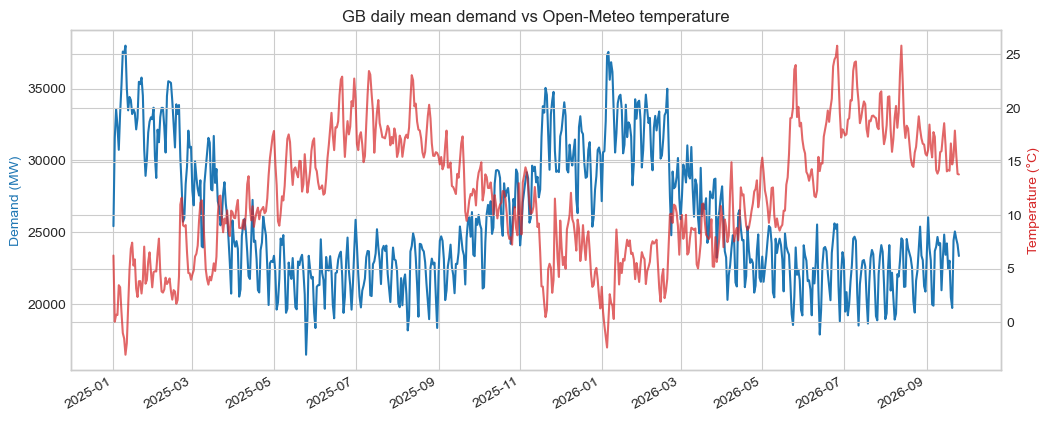

In [ ]:
merged = merge_demand_weather(demand, weather)
daily = merged.groupby("settlement_date", as_index=False).agg(
    demand_mw=("demand_mw", "mean"),
    temperature_2m=("temperature_2m", "mean"),
)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(daily["settlement_date"], daily["demand_mw"], color="tab:blue")
ax1.set_ylabel("Demand (MW)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(daily["settlement_date"], daily["temperature_2m"], color="tab:red", alpha=0.7)
ax2.set_ylabel("Temperature (°C)", color="tab:red")
ax1.set_title("GB daily mean demand vs Open-Meteo temperature")
fig.autofmt_xdate()
plt.show()